# EVAC Part 1

In [13]:
import numpy
import matplotlib.pyplot as plt
import random
from deap import base, creator, tools, algorithms
from scipy.stats import mannwhitneyu

# DATA

In [14]:
# Food,Cost,Protein,Fat,Carbohydrate,Calories
data = [
    ["Bread",2.0,4.0,1.0,15.0,90],

    ["Milk",3.5,8.0,5.0,11.7,120],

    ["Cheese",8.0,7.0,9.0,0.4,106],

    ["Potato",1.5,1.3,0.1,22.6,97],

    ["Fish",11.0,8.0,7.0,0.0,130],

    ["Yoghurt",1.0,9.2,1.0,17.0,180],
]

# Constraints
calories_min = 300
protein_max = 10
carbs_min = 10
fat_min = 8
fish_min = 0.5
milk_max = 1.0

# EVOLUTIONARY ALGORITHM

In [15]:
# GA Functions
def evalDiet(individual):
    '''
    Evaluate the diet by calculating total cost and checking constraints.
    * param individual: A list of amounts for each food item.
    * return: A tuple containing the total cost (or a high cost if constraints are violated).
    '''
    total_cost = 0
    total_protein = 0
    total_fat = 0
    total_carbs = 0
    total_calories = 0
    penalty = 100

    # Check for negative amounts and return high cost if found
    total_cost += sum(abs(amt) for amt in individual if amt < 0) * penalty

    # Calculate total cost and nutrients
    for i in range(len(data)):
        amount = max(0, individual[i]) # Ensure no negative amounts
        total_cost += amount * data[i][1]
        total_protein += amount * data[i][2]
        total_fat += amount * data[i][3]
        total_carbs += amount * data[i][4]
        total_calories += amount * data[i][5]

    # Check constraints and add penalties
    total_cost += penalty * (calories_min - total_calories) if total_calories < calories_min else 0
    total_cost += penalty * (total_protein - protein_max) if total_protein > protein_max else 0
    total_cost += penalty * (carbs_min - total_carbs) if total_carbs < carbs_min else 0
    total_cost += penalty * (fat_min - total_fat) if total_fat < fat_min else 0
    total_cost += penalty * (fish_min - individual[4]) if individual[4] < fish_min else 0
    total_cost += penalty * (individual[1] - milk_max) if individual[1] > milk_max else 0

    return total_cost,

In [16]:
#  Create fitness and individual
creator.create("Cost", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.Cost)

# Create toolbox and register functions
toolbox = base.Toolbox()
toolbox.register("food_amount", random.uniform, 0, 4) # maximum of 4 servings per food item as 4 of any item would exceed calorie constraints
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.food_amount, n=len(data))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evalDiet)
toolbox.register("select", tools.selTournament, tournsize=5)
toolbox.register("mate", tools.cxBlend, alpha=1.0)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.1)

# Tools setup for statistics and hall of fame
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
logbook = tools.Logbook()
hof = tools.HallOfFame(1)

stats.register("avg", numpy.mean)
stats.register("std", numpy.std)
stats.register("min", numpy.min)
stats.register("max", numpy.max)
logbook.header = "gen", "avg", "evals", "std", "min", "max"

In [17]:
# genetic algorithm parameters
NGEN = 200
POP_SIZE = 1000
CXPB = 0.5
MUTPB = 0.2
MU = 500
LAMBDA = 500

# Initial population log them as gen 0
pop = toolbox.population(POP_SIZE)
pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats, hof)
# pop, logbook = algorithms.eaMuCommaLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats, hof)
# pop, logbook = algorithms.eaSimple(pop, toolbox, CXPB, MUTPB, NGEN, stats, hof)

gen	nevals	avg    	std    	min    	max    
0  	1000  	6580.54	2055.12	1451.22	12382.5
1  	342   	3979.72	1239.36	1065   	8089.2 
2  	355   	2480.58	767.607	698.156	4590.26
3  	339   	1648.17	542.646	545.201	3390.61
4  	364   	1109.94	360.869	357.58 	2492.69
5  	351   	766.287	170.357	357.58 	1392.82
6  	342   	596.459	139.624	193.896	1066.36
7  	340   	438.579	125.571	120.273	728.336
8  	344   	309.277	80.0213	120.273	545.201
9  	355   	231.459	58.8805	119.828	391.926
10 	355   	178.064	37.7891	83.3346	306.499
11 	363   	143.112	31.9279	83.3346	216.86 
12 	358   	116.762	15.0917	77.9124	193.896
13 	352   	103.644	14.4167	63.7577	120.273
14 	369   	87.3379	11.4526	56.4071	119.828
15 	361   	76.913 	7.85849	40.7302	106.16 
16 	364   	68.4886	9.91414	40.5813	83.3346
17 	347   	58.0757	9.81672	27.3267	79.3242
18 	345   	47.3823	7.01621	27.3267	73.3358
19 	360   	41.1273	4.30546	27.3267	57.1487
20 	348   	37.0846	5.12366	27.3267	45.2783
21 	360   	31.8541	4.96375	26.3617	40.7302
22 	357   	

# RESULTS

In [18]:
# Get the best solution and output everything they chose, nutritional content and what cost they expended
best_ind = hof[0]
print("The best individual orders: Bread=%.2f, Milk=%.2f, Cheese=%.2f, Potato=%.2f, Fish=%.2f, Yoghurt=%.2f" % (
    best_ind[0], 
    best_ind[1], 
    best_ind[2], 
    best_ind[3], 
    best_ind[4], 
    best_ind[5]
))  
print("Nutritional content: Protein=%.2f, Fat=%.2f, Carbs=%.2f, Calories=%.2f" % (
    sum(max(0, best_ind[i]) * data[i][2] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][3] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][4] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][5] for i in range(len(data)))
))
print("With cost %s" % (best_ind.fitness.values))

The best individual orders: Bread=0.00, Milk=0.04, Cheese=0.46, Potato=1.86, Fish=0.50, Yoghurt=0.01
Nutritional content: Protein=10.00, Fat=8.00, Carbs=42.86, Calories=300.00
With cost 12.088098331484424


(10.0, 30.0)

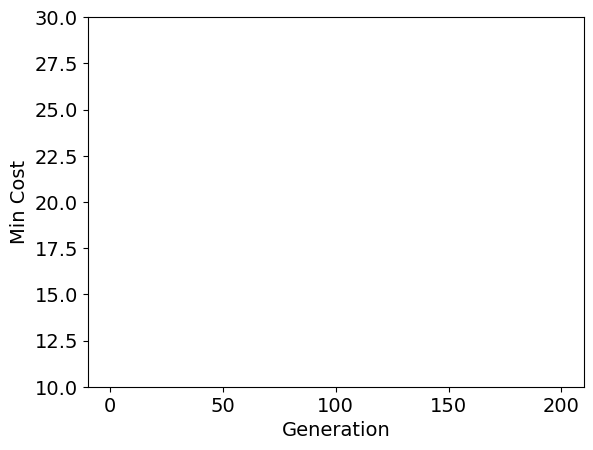

In [49]:
# Get data from logbook
gen = logbook.select("gen")
avgs = logbook.select("avg")
stds = logbook.select("std")
mins = logbook.select("min")

# Plotting
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
# Choosing min as mean is useless when we have such a large penalty for constaint violation
fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, mins)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Min Cost")
ax1.set_ylim(10, 30)

# Statistical Analysis

In [50]:
def run_experiment(cxpb, mut_prob, num_runs=30):
    '''
    Runs multiple independent experiments to gather stochastic performance data, 
    '''
    results = []
    for _ in range(num_runs):
        pop = toolbox.population(n=POP_SIZE)
        temp_hof = tools.HallOfFame(1)
        algorithms.eaSimple(pop, toolbox, cxpb=cxpb, mutpb=mut_prob, ngen=NGEN, stats=None, halloffame=temp_hof, verbose=False)
        results.append(temp_hof[0].fitness.values[0])
    return results

# Run the test
low_mut = run_experiment(CXPB, 0.1)
high_mut = run_experiment(CXPB, 0.5)

# Calculate P-Value
u_stat, p_val = mannwhitneyu(low_mut, high_mut)

print(f"P-Value: {p_val}") 

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

# Configuration
NUM_RUNS = 30
MU_VAL = 1000
LAMBDA_VAL = 2000  # Higher for comma strategy to ensure valid offspring pool
CXPB_FIXED = 0.5
MUTPB_FIXED = 0.2

def run_comparison():
    strategies = {
        "eaSimple": [],
        "eaMuPlusLambda": [],
        "eaMuCommaLambda": []
    }

    print("Starting experiments... this may take a moment.")

    for i in range(NUM_RUNS):
        # 1. Test eaSimple
        pop_simple = toolbox.population(n=POP_SIZE)
        hof_simple = tools.HallOfFame(1)
        algorithms.eaSimple(pop_simple, toolbox, CXPB_FIXED, MUTPB_FIXED, NGEN, 
                            stats=None, halloffame=hof_simple, verbose=False)
        strategies["eaSimple"].append(hof_simple[0].fitness.values[0])

        # 2. Test eaMuPlusLambda
        pop_plus = toolbox.population(n=MU_VAL)
        hof_plus = tools.HallOfFame(1)
        algorithms.eaMuPlusLambda(pop_plus, toolbox, mu=MU_VAL, lambda_=LAMBDA_VAL, 
                                  cxpb=CXPB_FIXED, mutpb=MUTPB_FIXED, ngen=NGEN, 
                                  stats=None, halloffame=hof_plus, verbose=False)
        strategies["eaMuPlusLambda"].append(hof_plus[0].fitness.values[0])

        # 3. Test eaMuCommaLambda
        pop_comma = toolbox.population(n=MU_VAL)
        hof_comma = tools.HallOfFame(1)
        algorithms.eaMuCommaLambda(pop_comma, toolbox, mu=MU_VAL, lambda_=LAMBDA_VAL, 
                                   cxpb=CXPB_FIXED, mutpb=MUTPB_FIXED, ngen=NGEN, 
                                   stats=None, halloffame=hof_comma, verbose=False)
        strategies["eaMuCommaLambda"].append(hof_comma[0].fitness.values[0])
        print(i,end="",flush=True)

    return strategies

# Execute
results = run_comparison()

# Statistical Analysis (Rigour)
# Compare Simple vs Plus
u_stat, p_plus = mannwhitneyu(results["eaSimple"], results["eaMuPlusLambda"])
# Compare Plus vs Comma
u_stat, p_comma = mannwhitneyu(results["eaMuPlusLambda"], results["eaMuCommaLambda"])

print(f"P-value (Simple vs Plus): {p_plus:.4f}")
print(f"P-value (Plus vs Comma): {p_comma:.4f}")

# Visualization (Effective Presentation)
plt.figure(figsize=(12, 7))
plt.boxplot([results["eaSimple"], results["eaMuPlusLambda"], results["eaMuCommaLambda"]], 
            labels=['eaSimple', 'ea(μ+λ)', 'ea(μ,λ)'])
plt.title('Comparison of Evolutionary Strategies on Diet Cost Optimization')
plt.ylabel('Total Diet Cost (£)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('strategy_comparison.png')
plt.show()

Starting experiments... this may take a moment.
01

KeyboardInterrupt: 

: 

: 

: 